## Framework Overview  

This framework is designed to streamline the **data preprocessing pipeline** by implementing multiple algorithms for:  

- **Data Cleansing**  
- **Outlier Detection & Handling**  
- **Feature Selection**  
- **Model Selection**  

At each step, we evaluate the effectiveness of different algorithms using a **shallow Decision Tree model** and  a **KNN Model**. This allows us to determine the best preprocessing strategy based on performance.  


## Importing Packages

In [51]:
# !pip3 install jdatetime

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import jdatetime #Convert From Jalali to Datetime
from sklearn.preprocessing import LabelEncoder # Encode y column
from dateutil.parser import parse #Detect Date Columns
from sklearn.model_selection import train_test_split #Weak Model Test
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score #Weak Model Test
from sklearn.tree import DecisionTreeClassifier #Weak Model Test
from sklearn.neighbors import KNeighborsClassifier #Weak Model Test
from sklearn.impute import SimpleImputer, KNNImputer #Handle Missing
from sklearn.linear_model import LinearRegression #Handle Missing
from sklearn.experimental import enable_iterative_imputer #Handle Missing(Imported Because of API Change)
from sklearn.impute import IterativeImputer #Handle Missing
from sklearn.neighbors import LocalOutlierFactor #Tame Outlier
from sklearn.ensemble import IsolationForest #Tame Outlier
from scipy.stats import zscore #Tame Outlier
from sklearn.preprocessing import RobustScaler,MinMaxScaler,StandardScaler # Nomalization
from sklearn.feature_selection import SelectKBest,f_classif,SelectFromModel,RFE,chi2,VarianceThreshold, mutual_info_classif # Feature Selection
from sklearn.svm import LinearSVC # Feature Selection
from sklearn.ensemble import ExtraTreesClassifier # Feature Selection
from sklearn.linear_model import LogisticRegression # Feature Selection
from sklearn.model_selection import GridSearchCV #Model Training
from sklearn.neural_network import MLPClassifier #Model Training
from sklearn.svm import SVC #Model Training
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier #Model Training
from sklearn.naive_bayes import GaussianNB #Model Training
from xgboost import XGBClassifier #Model Training
from sklearn.metrics import accuracy_score #Model Training
from lightgbm import LGBMClassifier #Model Training
from catboost import CatBoostClassifier #Model Training
from collections import Counter # Balanced Learning and Model Training
from imblearn.over_sampling import SMOTE, RandomOverSampler # Balanced Learning

## Plots

In [53]:
def plot_histograms_grouped(X,path ,bins=30, max_per_figure=10):
    num_features = X.shape[1]
    num_figures = int(np.ceil(num_features / max_per_figure))
    
    columns = X.columns.tolist()
    
    for fig_idx in range(num_figures):
        start = fig_idx * max_per_figure
        end = min(start + max_per_figure, num_features)
        subset_columns = columns[start:end]
        
        n_cols = 2
        n_rows = int(np.ceil(len(subset_columns) / n_cols))
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 4))
        axes = axes.flatten()

        for idx, column in enumerate(subset_columns):
            ax = axes[idx]
            ax.hist(X[column].dropna(), bins=bins, color='skyblue', edgecolor='black')
            ax.set_title(column)
            ax.grid(True, linestyle='--', alpha=0.7)

        for extra_idx in range(len(subset_columns), len(axes)):
            fig.delaxes(axes[extra_idx])
        plt.tight_layout()
        plt.savefig(f"{path}_histograms_{fig_idx}.png")
        plt.show()


In [54]:
def plot_pie_chart(series, path,title="Pie Chart Y Column"):
    """
    Plots a pie chart from a Pandas Series.
    
    Args:
        series (pd.Series): Series where index = labels, values = sizes.
        title (str): Title of the chart.
    """
    counts = series.value_counts()
    labels = counts.index
    sizes = counts.values

    plt.figure(figsize=(6,6))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
    plt.title(title)
    plt.axis('equal') 
    plt.savefig(f"{path}_{title}")
    plt.show()

## Handle Date Columns

In [55]:
def is_pure_date_string(s):
    try:
        s = s.strip()
        if any(char.isalpha() for char in s):
            return False
        Sep=""
        if("/" in s):
            Sep=s.split("/")
        elif("-" in s):
            Sep=s.split("-")
        else:
            return False
        if(len(Sep)==3):
            try:
                _,_,_=map(int,Sep)
                return True
            except:
                return False
    except:
        return False

def identify_date_columns(data):
    """Detect columns where all non-null values are pure date strings."""
    date_columns = []

    for col in data.select_dtypes(include=['object', 'string']):
        non_null_values = data[col].dropna()

        if non_null_values.apply(is_pure_date_string).all():
            date_columns.append(col)

    return date_columns

def convert_jalali_column_to_datetime(col):
    converted = []
    for val in col:
        try:
            val = str(val).strip()
            parts = val.split('/')
            if len(parts) == 3:
                year, month, day = map(int, parts)
                jdate = jdatetime.date(year, month, day).togregorian()
                dt = pd.Timestamp(jdate)
            else:
                dt = pd.NaT
        except:
            dt = pd.NaT
        converted.append(dt)
    return pd.Series(converted)

def detect_calendar_type(date_str):
    """
    Detects whether a date is likely Jalali or Gregorian based on year.
    Returns 'jalali', 'gregorian', or 'unknown'.
    """
    try:
        date_str = str(date_str).strip()
        parts=""
        if("/" in date_str):
            parts = date_str.split('/')
        elif("-" in date_str):
            parts = date_str.split('/')
        if len(parts) != 3:
            return 'unknown'
        year = int(parts[0])
        if 1200 <= year <= 1500:
            return 'jalali'
        elif 1800 <= year <= 2200:
            return 'gregorian'
        else:
            return 'unknown'
    except:
        return 'unknown'

def process_date_columns(data, reference_column=None):
    """ Processes the date columns and extracts useful time-based features."""

    date_columns=identify_date_columns(data)
    if(len(date_columns)==0):
        return data
    typeCal=detect_calendar_type((data[date_columns[0]].values)[0])
    if(typeCal=="jalali"):
        for col in date_columns:
            data[col] = convert_jalali_column_to_datetime(data[col])
    else:
        for col in date_columns:
            data[col] = pd.to_datetime(data[col], errors='coerce')

    for col in date_columns:
        data[f'{col}_year'] = data[col].dt.year.astype(float)
        data[f'{col}_month'] = data[col].dt.month.astype(float)
        data[f'{col}_day'] = data[col].dt.day.astype(float)
        data[f'{col}_day_of_week'] = data[col].dt.dayofweek.astype(float)
        data[f'{col}_hour'] = data[col].dt.hour.astype(float)
        data[f'{col}_day_of_year'] = data[col].dt.dayofyear.astype(float)
        data[f'{col}_is_weekend'] = (data[col].dt.weekday >= 5).astype(float)


    if reference_column:
        for col in date_columns:
            data[f'{col}_time_diff'] = (data[reference_column] - data[col]).dt.total_seconds() / (60 * 60 * 24)

    return data.drop(columns=date_columns)

## Convert into Numeric Values

In [56]:
def ConvertToNumeric(data):
    data=process_date_columns(data)
    cols = data.columns
    num_cols = data._get_numeric_data().columns
    categorical_columns = list(set(cols) - set(num_cols))

    for column in categorical_columns:
        categories = list(data[column].dropna().astype(str).unique())
        mapping = {cat: idx for idx, cat in enumerate(categories)}
        
        print(f"\nMapping for column '{column}':")
        for cat, idx in mapping.items():
            print(f"  {cat}: {idx}")
    
        data[column] = data[column].map(lambda x: mapping.get(str(x), x))

    return data

def sanitize_column_names(data):
    data.columns = [re.sub(r'[^\w]', '_', col) for col in data.columns]
    return data

## Loading Data

In [57]:
def load_data(path, y_column):
    if("csv" in path):
        data=pd.read_csv(path, na_values=[" ", "", "NA", "NaN"])
    elif("xlsx" in path):
        data=pd.read_excel(path,na_values=[" ", "", "NA", "NaN"])
    else:
        print("Format not Supported")
        return None
    threshold = 2
    valid_cols = data.columns[data.notna().sum() >= threshold]
    data = data[valid_cols]
    data=sanitize_column_names(data)
    data=ConvertToNumeric(data)
    le = LabelEncoder()
    data[y_column] = le.fit_transform(data[y_column])
    Y=data[y_column]
    X=data.drop(columns=y_column)

    return X,Y,data

## Implementing Test Models

In [58]:
def train_and_evaluate(X, y, expand=False):
    """Trains multiple weak models (3x KNN and 3x Decision Tree) and evaluates them."""

    if len(y) <= 5 or len(X) <= 5:
        return 0

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    models = [
        KNeighborsClassifier(n_neighbors=3),
        KNeighborsClassifier(n_neighbors=5),
        KNeighborsClassifier(n_neighbors=7),

        DecisionTreeClassifier(max_depth=3, random_state=42),
        DecisionTreeClassifier(max_depth=5, random_state=42),
        DecisionTreeClassifier(max_depth=None, min_samples_split=10, random_state=42),

    ]

    all_scores = []

    for i, model in enumerate(models):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=1)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=1)
        f1 = f1_score(y_test, y_pred, average='weighted')
        coefs_scores=[1,1,1,1]
        all_scores.extend([acc*coefs_scores[0], prec*coefs_scores[1], rec*coefs_scores[2], f1*coefs_scores[3]])

        if expand:
            print(f"\nModel {i+1}: {model.__class__.__name__}")
            print(f"  Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-score: {f1:.4f}")

    weighted_score = sum(all_scores) / len(all_scores)

    return weighted_score


# Handling Missing Data

These functions help clean our dataset by handling missing values efficiently and selecting the best imputation method.

## Available Algorithms  
- **Dropping Methods:**  
  - Drop columns with null values exceeding a threshold  
  - Drop rows with missing values  

- **Statistical Imputation:**  
  - Impute with **mean** or **median**  
  - Impute with **class-specific mean** or **median**  

- **Forward & Backward Filling:**  
  - **Forward fill (ffill)**  
  - **Backward fill (bfill)**  
  - **Interpolate** missing values  

- **Model-Based Imputation:**  
  - **Model Imputation** (predict missing values using a simple model)  
  - **Iterative Model Imputation** (refines predictions iteratively)  
  - **KNN Imputation** (fills missing values based on k-nearest neighbors)  


In [59]:
def drop_rows(X, Y):
    """Drops rows with any missing values."""

    mask=X.notna().all(axis=1)
    return X[mask], Y[mask]

def impute_mean(X, Y):
    """Fills missing values with column mean while leaving non-missing values intact."""


    imputer = SimpleImputer(strategy="mean")
    X_imputed = imputer.fit_transform(X)
    X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

    X_filled = X.copy()
    for col in X.columns:
        X_filled[col] = np.where(X[col].isna(), X_imputed_df[col], X_filled[col])

    return X_filled,Y

def impute_median(X, Y):
    """Fills missing values with column median while leaving non-missing values intact."""


    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X)
    X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

    X_filled = X.copy()
    for col in X.columns:
        X_filled[col] = np.where(X[col].isna(), X_imputed_df[col], X_filled[col])

    return X_filled,Y

def impute_class_mean(X, Y):
    """Fills missing values with the mean of each class in Y, ensuring no NaNs remain."""


    X_copy = X.copy()
    for col in X.columns:
        grouped_means = X.groupby(Y)[col].transform(lambda x: x.mean())
        X_copy[col] = X[col].fillna(grouped_means)  # Fill NaNs with class mean

        if X_copy[col].isna().sum() > 0:
            X_copy[col].fillna(X[col].mean(), inplace=True)

    return X_copy, Y

def impute_class_median(X, Y):
    """Fills missing values with the median of each class in Y."""


    X_copy = X.copy()
    for col in X.columns:
        X_copy[col] = X.groupby(Y)[col].transform(lambda x: x.fillna(x.median()))

        if X_copy[col].isna().sum() > 0:
            X_copy[col].fillna(X[col].mean(), inplace=True)
    return X_copy,Y

def ffill(X, Y):
    """Fills missing values with the previous row (forward fill) and ensures no NaNs remain."""

    X_filled = X.ffill()
    X_filled = X_filled.bfill()
    return X_filled, Y

def bfill(X, Y):
    """Fills missing values with the next row (backward fill)."""

    X_filled = X.bfill()
    X_filled = X_filled.ffill()
    return X_filled,Y

def interpolate(X, Y):
    """Interpolates missing values linearly and ensures no NaNs remain."""


    X_filled = X.interpolate(method="linear", limit_direction="both")
    return X_filled, Y



def Model_imputation(X, Y):
    """Uses a simple regression model to impute missing values."""

    X_copy = X.copy()

    for col in X_copy.columns:
        missing_mask = X_copy[col].isna()
        if missing_mask.sum() > 0:
            known_data = X_copy[~missing_mask].copy()
            known_X = known_data.drop(columns=[col])
            known_y = known_data[col]

            known_X = known_X.apply(lambda col: col.fillna(col.mean()), axis=1)

            missing_X = X_copy.loc[missing_mask].drop(columns=[col])
            missing_X = missing_X.fillna(known_X.mean())

            if len(known_X) > 0 and len(missing_X) > 0:
                model = LinearRegression()
                model.fit(known_X, known_y)
                X_copy.loc[missing_mask, col] = model.predict(missing_X)

    return X_copy, Y

def Iterative_model_Imputation(X, Y):
    """Uses iterative imputation (sklearn's IterativeImputer) to fill only null values."""


    imputer = IterativeImputer()
    X_imputed = imputer.fit_transform(X)
    X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

    X_filled = X.copy()

    for col in X.columns:
        X_filled[col] = np.where(X[col].isna(), X_imputed_df[col], X_filled[col])

    return X_filled,Y

def KNN_Imputation(X, Y, n_neighbors=5):
    """Uses KNN to fill missing values while leaving non-missing values intact."""


    imputer = KNNImputer(n_neighbors=n_neighbors)
    X_imputed = imputer.fit_transform(X)
    X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

    X_filled = X.copy()

    for col in X.columns:
        X_filled[col] = np.where(X[col].isna(), X_imputed_df[col], X_filled[col])

    return X_filled,Y

algorithm_functions_clean_data = {
    "drop_rows": drop_rows,
    "impute_mean": impute_mean,
    "impute_median": impute_median,
    "impute_class_mean": impute_class_mean,
    "impute_class_median": impute_class_median,
    "ffill": ffill,
    "bfill": bfill,
    "interpolate": interpolate,
    "Model_imputation": Model_imputation,
    "Iterative_model_Imputation": Iterative_model_Imputation,
    "KNN_Imputation": KNN_Imputation,
}


In [60]:
def track_changes(original_X, new_X):
    changes = []
    for col_idx, col in enumerate(original_X.columns):
        modified = original_X[col] != new_X[col]
        for row_idx in modified[modified].index:
            changes.append((row_idx, col_idx))
    return changes

def handling_missing_data(X, Y):
    """Applies different missing data handling algorithms, selects the best one, and returns the transformed dataset."""

    if(X.isna().sum().sum()==0):
        return X,Y,"No Null Data",100,{"No Null Data":100}
    
    Y = Y.dropna(inplace=False)

    X = X.loc[Y.index]
    threshold = 2
    valid_cols = X.columns[X.notna().sum() >= threshold]
    only_nan = list(set(X.columns) - set(valid_cols))
    X=X.drop(columns=only_nan)

    x_copy = X.copy()
    y_copy = Y.copy()
    acc_holder = {}

    best_algo = None
    best_accuracy = -1

    for name, func in algorithm_functions_clean_data.items():
        print(name)
        print()
        X_transformed,Y_transformed = func(x_copy.copy(), y_copy.copy())
        accuracy = train_and_evaluate(X_transformed, Y_transformed,expand=False)
        acc_holder[name] = accuracy

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_algo = name
    if best_algo:
        x_copy,y_copy = algorithm_functions_clean_data[best_algo](x_copy.copy(), y_copy.copy())
        changes=track_changes(X,x_copy)

    return x_copy, y_copy, best_algo, best_accuracy,acc_holder,changes

# Taming Outliers

These functions help clean our dataset from outliers efficiently and selecting the best outlier detection algorithm.

## Available Algorithms  
- **IQR Method(1.5):**  
  - Take 1.5 times the IQR and then subtract this value from Q1 and add this value to Q3


- **LOF:**  
  - For any data object **q**, the **LOF score** is computed as the ratio of the **average local density** of its **k-nearest neighbors** to its **own local density** **[25]**.  

  $$
  LOF(q) = \frac{\sum_{x \in N_k(q)} lrd(x)}{|N_k(q)| \times lrd(q)}
  $$

  where the **local reachability density (lrd)** of **q** is given by:  

  $$
  lrd(q) = \frac{|N_k(q)|}{\sum_{x \in N_k(q)} \max(\text{dist}_k(x, D), \text{dist}(q, x))}
  $$

- **SP:**  
   - Employ a **scoring measure** based on the nearest neighbor (**k = 1**) within random sub-samples (**S ⊂ D**).  

    $$  S_p(q) = \min_{{x \in S}} \text{dist}(q, x) $$

    where **dist(q, x)** represents the distance between **q** and **x**.

- **iForest:**  
  - A **random split** is performed on a randomly selected feature.  
  - The partitioning continues until either:  
    - Each node contains only **one data object**, or  
    - The tree reaches its **height limit**.

  $$
  iForest(q) = \frac{1}{t} \sum_{i=1}^{t} l_i(q)
  $$


- **iNNe:**  
  - This method builds **hyperspheres** using all dimensions of the dataset. The **isolation score** of a data object **q** is defined as:  

  $$
  I(q) =
  \begin{cases}
  \tau (\eta_{cnn}(q)), & \text{if } q \in \bigcup_{c \in S} B(c) \\  
  1 - \tau (cnn(q)), & \text{otherwise}  
  \end{cases}
  $$


In [61]:
def IQR(X, Y):
    """Adjust outliers based on IQR min-max whiskers."""
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    min_whisker = Q1 - 2.2 * IQR
    max_whisker = Q3 + 2.2 * IQR
    X_adjusted = X.clip(lower=min_whisker, upper=max_whisker, axis=1)
    return X_adjusted, Y

def LOF(X, Y):
    """Adjust only the detected outliers based on LOF anomaly score."""
    clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
    X_scores = clf.fit_predict(X)
    adjustment_factor = np.abs(clf.negative_outlier_factor_) / np.max(np.abs(clf.negative_outlier_factor_))

    X_adjusted = X.copy()
    outlier_mask = X_scores == -1
    X_adjusted[outlier_mask] = X[outlier_mask] * (1 - adjustment_factor[outlier_mask, np.newaxis])
    return X_adjusted, Y

def IsolationForestOutlier(X, Y):
    """Only adjust outliers based on Isolation Forest isolation score."""
    iso = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
    preds = iso.fit_predict(X)
    scores = iso.decision_function(X)

    adjustment_factor = (scores - scores.min()) / (scores.max() - scores.min())
    X_adjusted = X.copy()

    for i, pred in enumerate(preds):
        if pred == -1:
            X_adjusted.iloc[i] = X.iloc[i] * (1 - adjustment_factor[i])

    return X_adjusted, Y



def SP(X, Y):
    """Adjust only outliers beyond 3 std dev using Standardization Projection."""
    X_adjusted = X.copy()
    Z_scores = np.abs(zscore(X, nan_policy='omit'))
    Z_scores = np.nan_to_num(Z_scores, nan=0)

    for col in X.columns:
        col_idx = X.columns.get_loc(col)
        for i in range(len(X)):
            if Z_scores[i, col_idx] > 3:
                factor = 3 / Z_scores[i, col_idx]
                X_adjusted.iloc[i, col_idx] = X.iloc[i, col_idx] * factor

    return X_adjusted, Y


def IsolationNNe(X, Y):
    """Only adjust outliers based on Isolation Forest distance score."""
    iso = IsolationForest(contamination=0.05, n_estimators=200, random_state=42)
    preds = iso.fit_predict(X)
    dist = iso.decision_function(X)
    adjustment_factor = np.abs(dist) / np.max(np.abs(dist))

    X_adjusted = X.copy()
    for i, pred in enumerate(preds):
        if pred == -1:
            X_adjusted.iloc[i] = X.iloc[i] * (1 - adjustment_factor[i])

    return X_adjusted, Y


algorithm_functions_tame_outlier = {
    "IQR": IQR,
    "LOF": LOF,
    "iForest": IsolationForestOutlier,
    "SP": SP,
    "iNNe": IsolationNNe,
}


In [62]:
def track_changes(original_X, new_X):
    changes = []
    for col_idx, col in enumerate(original_X.columns):
        modified = original_X[col] != new_X[col]
        for row_idx in modified[modified].index:
            changes.append((row_idx, col_idx))
    return changes

def taming_outliers(X,Y):
    acc_holder = {}
    x_copy = X.copy()
    y_copy = Y.copy()
    best_algo = None
    best_accuracy = 0


    for name, func in algorithm_functions_tame_outlier.items():
        print(name)
        print()

        X_Adjusted,Y_Adjusted = func(x_copy.copy(), y_copy.copy())
        accuracy = train_and_evaluate(X_Adjusted, Y_Adjusted,expand=False)
        acc_holder[name] = accuracy


        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_algo = name
    if best_algo:
        x_copy,y_copy = algorithm_functions_tame_outlier[best_algo](x_copy.copy(), y_copy.copy())

    changes=track_changes(x_copy,X)
    return x_copy, y_copy, best_algo, best_accuracy,acc_holder,changes

# Normalization Algorithms

These functions help standardize or normalize datasets to improve model performance and feature scaling.

## Available Algorithms

### 1. MinMaxScalarNorm
- **Description:**
  - Scales features to a fixed range [0, 1] using minimum and maximum values
  - Formula:
    $$
    X_norm = (X - X_min) / (X_max - X_min)
    $$


### 2. RobustScalarNorm
- **Description:**
  - Scales features using median and interquartile range (IQR) to handle outliers
  - Formula:
    $$
    X_robust = (X - Median(X)) / IQR(X)
    $$


### 3. ZScoreNormalizationNorm
- **Description**:
  - Standardizes features to have zero mean and unit variance
  - Formula:
    $$
    X_std = (X - μ) / σ
    $$


In [63]:
def MinMaxScalarNorm(X,Y):
  scaler = MinMaxScaler()
  scaler.fit(X)
  return pd.DataFrame(scaler.transform(X),columns=X.columns,index=X.index),Y

def RobustScalarNorm(X, Y):
    transformer = RobustScaler(with_centering=True, with_scaling=True)
    X_transformed = transformer.fit_transform(X)
    denom = X_transformed.max(axis=0) - X_transformed.min(axis=0)
    denom[denom == 0] = 1
    X_scaled = (X_transformed - X_transformed.min(axis=0)) / denom
    return pd.DataFrame(X_scaled, columns=X.columns, index=X.index), Y

def ZScoreNormalizationNorm(X, Y):
    scaler = StandardScaler()
    X_transformed = scaler.fit_transform(X)
    denom = X_transformed.max(axis=0) - X_transformed.min(axis=0)
    denom[denom == 0] = 1
    X_scaled = (X_transformed - X_transformed.min(axis=0)) / denom
    return pd.DataFrame(X_scaled, columns=X.columns, index=X.index), Y


algorithm_functions_normalization = {
    "MinMaxScalarNorm": MinMaxScalarNorm,
    "RobustScalarNorm": RobustScalarNorm,
    "ZScoreNormalizationNorm": ZScoreNormalizationNorm,
}

In [64]:
def normalization(X,Y):
    acc_holder = {}
    x_copy = X.copy()
    y_copy = Y.copy()
    best_algo = None
    best_accuracy = 0


    for name, func in algorithm_functions_normalization.items():
        print(name)
        print()

        X_Adjusted,Y_Adjusted = func(x_copy.copy(), y_copy.copy())

        accuracy = train_and_evaluate(X_Adjusted, Y_Adjusted,expand=False)
        acc_holder[name] = accuracy


        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_algo = name
    if best_algo:
        x_copy,y_copy = algorithm_functions_normalization[best_algo](x_copy.copy(), y_copy.copy())

    return x_copy, y_copy, best_algo, best_accuracy,acc_holder

# 📊 Feature Selection Algorithms

These functions help select the most relevant features from a dataset to improve model performance and reduce dimensionality.

## Available Algorithms

---

### 1. $ SelectK $
- **Description:**
  - Selects the top K features based on statistical tests (e.g., `chi2`, `f_classif`)
  - Uses univariate statistical tests to score each feature

- **Parameters:**
  - `k`: Number of top features to select  
  - `score_func`: Scoring function (default: `f_classif`)

---

### 2. $ L_1 Based $
- **Description:**
  - Selects features using L1-regularized linear models (e.g., Lasso, Logistic Regression)
  - Features with non-zero coefficients are selected

- **Parameters:**
  - `estimator`: L1-regularized model (e.g., `LogisticRegression`, `Lasso`)  
  - `threshold`: Minimum coefficient value for selection

---

### 3. $ TreeBased $
- **Description:**
  - Selects features based on importance scores from tree-based models
  - Uses the `feature_importances_` attribute from tree estimators

- **Parameters:**
  - `estimator`: Tree-based model (e.g., `RandomForest`, `XGBoost`)  
  - `threshold`: Minimum importance score for selection

---

### 4. $ RFE (Recursive Feature Elimination) $
- **Description:**
  - Recursively removes least important features using a base model
  - Fits the model multiple times and eliminates features with the smallest weights

- **Parameters:**
  - `estimator`: Model used to evaluate feature importance (default: `LogisticRegression`)  
  - `n_features_to_select`: Number of features to retain

---

### 5. $ Chi2 $
- **Description:**
  - Selects top K features using the Chi-squared statistical test
  - Suitable for non-negative, categorical or count data

- **Parameters:**
  - `k`: Number of top features to select

---

### 6. $ VarianceThreshold $
- **Description:**
  - Removes features with low variance, assuming low-variance features do not carry useful information
  - Filters features below a specified threshold

- **Parameters:**
  - `threshold`: Minimum variance required to keep a feature

---

### 7. $ Mutual Information $
- **Description:**
  - Measures the mutual dependency between feature and target
  - Captures non-linear relationships between variables

- **Parameters:**
  - `k`: Number of top features to select


In [65]:
def SelectK(X, Y, k):
    selector = SelectKBest(f_classif, k="all")
    selector.fit(X.values, Y)
    selected_X = selector.transform(X.values)
    scores = selector.scores_
    return pd.DataFrame(selected_X, columns=X.columns[selector.get_support()]), Y, scores


def L1_Based(X, Y, k):
    lsvc = LinearSVC(C=0.01, penalty="l1", dual=False, max_iter=2000).fit(X.values, Y)
    model = SelectFromModel(lsvc, prefit=True)
    selected_X = model.transform(X.values)
    coefs = np.abs(lsvc.coef_).mean(axis=0)
    return pd.DataFrame(selected_X, columns=X.columns[model.get_support()]), Y, coefs


def TreeBased(X, Y, k):
    clf = ExtraTreesClassifier(n_estimators=50)
    clf.fit(X.values, Y)
    model = SelectFromModel(clf, prefit=True)
    selected_X = model.transform(X.values)
    importances = clf.feature_importances_
    return pd.DataFrame(selected_X, columns=X.columns[model.get_support()]), Y, importances

def RFE_FeatureSelection(X, Y, k):
    model = LogisticRegression(max_iter=1000)
    selector = RFE(model, n_features_to_select=int(X.shape[1] * 0.5), step=1)
    selector.fit(X, Y)
    selected_X = selector.transform(X)
    return pd.DataFrame(selected_X, columns=X.columns[selector.get_support()]), Y, selector.ranking_

def Chi2_Selection(X, Y, k):
    if (X < 0).any().any():
        print("Negative values detected in X. Skipping chi2.")
        zero_scores = np.zeros(X.shape[1])
        return X, Y, zero_scores

    scores, _ = chi2(X, Y)
    score_series = pd.Series(scores, index=X.columns)
    top_k_features = score_series.nlargest(k).index
    selected_X = X[top_k_features]
    return selected_X, Y, scores

def VarianceThresh(X, Y, k):
    selector = VarianceThreshold(threshold=0.01)
    selected_X = selector.fit_transform(X)
    return pd.DataFrame(selected_X, columns=X.columns[selector.get_support()]), Y, selector.variances_

def MutualInfo(X, Y, k):
    scores = mutual_info_classif(X, Y)
    score_series = pd.Series(scores, index=X.columns)
    top_k_features = score_series.nlargest(k).index
    selected_X = X[top_k_features]

    return selected_X, Y, score_series

algorithm_functions_feature_selection = {
    "SelectK": SelectK,
    "L1_Based": L1_Based,
    "TreeBased": TreeBased,
    "RFE_FeatureSelection":RFE_FeatureSelection,
    "Chi2_Selection":Chi2_Selection,
    "VarianceThresh":VarianceThresh
}

In [66]:
def feature_selection(X, Y, categories):
    """Removes features that have the same value in all samples."""

    def remove_constant_features(X):
        return X.loc[:, X.nunique(dropna=False) > 1]

    acc_holder = {}
    X = remove_constant_features(X)
    y_copy = Y.copy()
    best_algo = None
    best_accuracy = 0

    selected_columns = []
    category_score_maps = {} 
    final_scores = np.zeros(len(X.columns))
    feature_names = X.columns.tolist()

    for cat in categories:
        cat_name = cat["name"]
        cat_cols = [col for col in cat["columns"] if col in X.columns]
        num_to_select = cat["num"]

        if len(cat_cols) == 0 or num_to_select == 0:
            continue

        x_cat = X[cat_cols].copy()
        cat_scores_accumulator = np.zeros(len(x_cat.columns))
        for name, func in algorithm_functions_feature_selection.items():
            k = min(len(cat_cols), len(x_cat.columns))
            X_Adjusted, Y_Adjusted, Scores = func(x_cat.copy(), y_copy.copy(), k)

            if Scores.min() == Scores.max():
                accuracy = 0
            else:
                norm_scores = (Scores - Scores.min()) / (Scores.max() - Scores.min())
                accuracy = train_and_evaluate(X_Adjusted, Y_Adjusted, expand=False)
                cat_scores_accumulator += norm_scores * accuracy

            acc_holder[f"{cat_name}_{name}"] = accuracy
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_algo = name

        score_map = dict(zip(x_cat.columns, cat_scores_accumulator))
        category_score_maps[cat_name] = score_map
        sorted_cols = sorted(score_map.items(), key=lambda x: x[1], reverse=True)
        top_n_cols = [col for col, _ in sorted_cols[:num_to_select]]
        selected_columns.extend(top_n_cols)

    x_selected = X[selected_columns]
    final_acc = train_and_evaluate(x_selected, y_copy, expand=False)

    final_result = f"Selected {len(selected_columns)} features: {selected_columns}"
    print(final_result)

    return x_selected, y_copy, best_algo, best_accuracy, acc_holder, final_acc, final_result

In [67]:
def is_imbalanced(y, threshold=0.1):
    class_counts = Counter(y)
    majority = max(class_counts.values())
    for count in class_counts.values():
        if (majority - count) / majority > threshold:
            return True
    return False

def apply_balancing(x_train, y_train, method='smote'):
    if method == 'smote':
        sampler = SMOTE(random_state=42)
    elif method == 'random':
        sampler = RandomOverSampler(random_state=42)
    else:
        raise ValueError("Unsupported balancing method. Use 'smote' or 'random'.")
    
    x_res, y_res = sampler.fit_resample(x_train, y_train)
    return x_res, y_res

def check_and_balance(x_train, y_train, method_selection_fn):
    if not is_imbalanced(y_train):
        print("Data appears to be balanced.")
        return x_train, y_train, 'none'
    
    print("Class imbalance detected. Testing balancing methods...")

    methods = ['random', 'smote']
    best_score = -np.inf
    best_method = 'random'
    best_x, best_y = x_train, y_train

    for method in methods:
        if(method=="none"):
            x_try, y_try = x_train,y_train
        else:
            x_try, y_try = apply_balancing(x_train, y_train, method)
        
        score = method_selection_fn(x_try, y_try)
        print(f"Method: {method}, Score: {score:.4f}")

        if score > best_score:
            best_score = score
            best_method = method
            best_x, best_y = x_try, y_try

    print(f"Best balancing method: {best_method} with score: {best_score:.4f}")
    return best_x, best_y, best_method


In [68]:
def is_imbalanced(y, threshold=0.25):
    counter = Counter(y)
    values = list(counter.values())
    if len(values) != 2:
        return False
    minority_ratio = min(values) / sum(values)
    return minority_ratio < threshold

def custom_score(y_true, y_pred, num_classes):
    average = "weighted" if num_classes != 2 else "binary"
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred, average=average,zero_division=0)
    prec = precision_score(y_true, y_pred, average=average,zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average)
    weighted_sum = rec+prec+acc+f1
    return weighted_sum / 4

def run_model_with_grid_search(model_name, model, param_grid, x_train, x_test, y_train, y_test, return_model, num_classes):
    if is_imbalanced(y_train):
        if "class_weight" in model.get_params().keys():
            param_grid["class_weight"] = ["balanced"]
        if model_name == "XGBoostBased":
            neg, pos = np.bincount(y_train)
            param_grid["scale_pos_weight"] = [neg / pos]

    total_combinations = np.prod([len(v) for v in param_grid.values()])
    print(f"Running {model_name} with {total_combinations} model configurations...")
    grid = GridSearchCV(model, param_grid, cv=2)
    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    score = custom_score(y_test, y_pred, num_classes)
    print(f"{model_name} custom score: {score:.4f}")
    return (score, best_model) if return_model else (score, None)

def NeuralNetworkBased(x_train, x_test, y_train, y_test, return_model, num_classes):
    param_grid = {
        'hidden_layer_sizes': [(50,), (100,), (50, 50)],
        'activation': ['relu', 'tanh'],
        'solver': ['adam'],
        'max_iter': [300]
    }
    return run_model_with_grid_search("NeuralNetworkBased", MLPClassifier(random_state=42), param_grid, x_train, x_test, y_train, y_test, return_model, num_classes)

def SVMBased(x_train, x_test, y_train, y_test, return_model, num_classes):
    param_grid = {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    }
    return run_model_with_grid_search("SVMBased", SVC(), param_grid, x_train, x_test, y_train, y_test, return_model, num_classes)

def RandomForestBased(x_train, x_test, y_train, y_test, return_model, num_classes):
    param_grid = {
        'n_estimators': [50, 100],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }
    return run_model_with_grid_search("RandomForestBased", RandomForestClassifier(random_state=42), param_grid, x_train, x_test, y_train, y_test, return_model, num_classes)

def XGBoostBased(x_train, x_test, y_train, y_test, return_model, num_classes):
    param_grid = {
        'n_estimators': [50, 100],
        'max_depth': [3, 6, 10],
        'learning_rate': [0.01, 0.1, 0.2]
    }
    return run_model_with_grid_search("XGBoostBased", XGBClassifier(use_label_encoder=True, eval_metric='mlogloss'), param_grid, x_train, x_test, y_train, y_test, return_model, num_classes)

def LogisticRegressionBased(x_train, x_test, y_train, y_test, return_model, num_classes):
    param_grid = {
        'penalty': ['l1', 'l2', 'elasticnet'],
        'C': [0.001, 0.01, 0.1, 1, 10],
        'solver': ['saga'],
        'max_iter': [1000],
        'l1_ratio': [0, 0.5, 1]
    }
    return run_model_with_grid_search("LogisticRegression", LogisticRegression(), param_grid, x_train, x_test, y_train, y_test, return_model, num_classes)

def KNNBased(x_train, x_test, y_train, y_test, return_model, num_classes):
    param_grid = {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree', 'kd_tree']
    }
    return run_model_with_grid_search("KNeighbors", KNeighborsClassifier(), param_grid, x_train, x_test, y_train, y_test, return_model, num_classes)

def NaiveBayesBased(x_train, x_test, y_train, y_test, return_model, num_classes):
    param_grid = {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    }
    return run_model_with_grid_search("GaussianNB", GaussianNB(), param_grid, x_train, x_test, y_train, y_test, return_model, num_classes)

def LightGBMBased(x_train, x_test, y_train, y_test, return_model, num_classes):
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'num_leaves': [31, 63],
        'max_depth': [-1, 3, 5, 10, 20]
    }
    return run_model_with_grid_search("LightGBM", LGBMClassifier(random_state=42,class_weight="balanced", verbose=-1), param_grid, x_train, x_test, y_train, y_test, return_model, num_classes)

def CatBoostBased(x_train, x_test, y_train, y_test, return_model, num_classes):
    param_grid = {
        'iterations': [100, 200],
        'learning_rate': [0.01, 0.1],
        'depth': [4, 6, 8]
    }
    return run_model_with_grid_search("CatBoost", CatBoostClassifier(silent=True,allow_writing_files=False), param_grid, x_train, x_test, y_train, y_test, return_model, num_classes)

def GradientBoostingBased(x_train, x_test, y_train, y_test, return_model, num_classes):
    param_grid = {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }
    return run_model_with_grid_search("GradientBoosting", GradientBoostingClassifier(), param_grid, x_train, x_test, y_train, y_test, return_model, num_classes)

algorithm_functions_model_training = {
    "LogisticRegression": LogisticRegressionBased,
    "KNN": KNNBased,
    "NaiveBayes": NaiveBayesBased,
    "RandomForest": RandomForestBased,
    "XGBoost": XGBoostBased,
    "LightGBM": LightGBMBased,
    "CatBoost": CatBoostBased,
    "GradientBoosting": GradientBoostingBased,
    "NeuralNetwork": NeuralNetworkBased,
    # "SVM": SVMBased,
}

In [69]:
def model_training(x_train,x_test,y_train,y_test):
    acc_holder = {}
    best_algo = None
    best_accuracy = 0
    num_classes = pd.concat([y_train, y_test]).nunique()

    for name, func in algorithm_functions_model_training.items():
        print(name)
        print()

        accuracy,model = func(x_train.copy(),x_test.copy(),y_train.copy(),y_test.copy(),return_model=False,num_classes=num_classes)

        acc_holder[name] = accuracy

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_algo = name

    if best_algo:
        accuracy,model = algorithm_functions_model_training[best_algo](x_train.copy(),x_test.copy(),y_train.copy(),y_test.copy(),return_model=True,num_classes=num_classes)

    return model, best_algo, best_accuracy,acc_holder

In [70]:
path="./WithoutLeakage/cvd_without_leakage"
typeData="csv"
normalized=True
y_column="CVD"


In [71]:
# X,Y,data=load_data(path='./Shariati_final_results.xlsx',y_column='کووید 19-RT-PCR(COVID-19)')
# X,Y,data=load_data(path="data1_1.csv",y_column="smokingstutus")
# X,Y,data=load_data(path="diabetes.csv",y_column="Outcome")
X,Y,data=load_data(path=f"{path}.{typeData}",y_column=y_column)
# X,Y,data=load_data(path="./healthcare_dataset.csv",y_column="Test Results")


In [72]:
X=X.astype("float64")

In [73]:
X.columns

Index(['FileNo', 'Age', 'Sex', 'Smoking_Status', 'BMI', 'WC', 'SBP', 'DBP',
       'AnxietyScore', 'DepressionScore', 'LDL', 'Glucose', 'Uric_Acid',
       'Cholesterol', 'hs_CRP', 'HDL', 'TG', 'PAL', 'PAB', 'GFR',
       'Nightly_Sleep'],
      dtype='object')

In [74]:
categories = [
    {"name": "Social","num":5, "columns": ["SBP", "DBP", "AnxietyScore", "DepressionScore", "hs_CRP", "PAL"]},
    {"name": "Cardio Vascular","num":3, "columns": ["Age", "Sex", "LDL", "Uric_Acid", "Cholesterol", "HDL", "GFR"]},
    {"name": "Blood","num":7,"columns": ["Smoking_Status", "BMI", "WC", "Glucose", "TG", "PAB", "Nightly_Sleep"]},
]
cols_to_drop=['FileNo']


In [75]:
X.drop(columns=cols_to_drop,inplace=True)

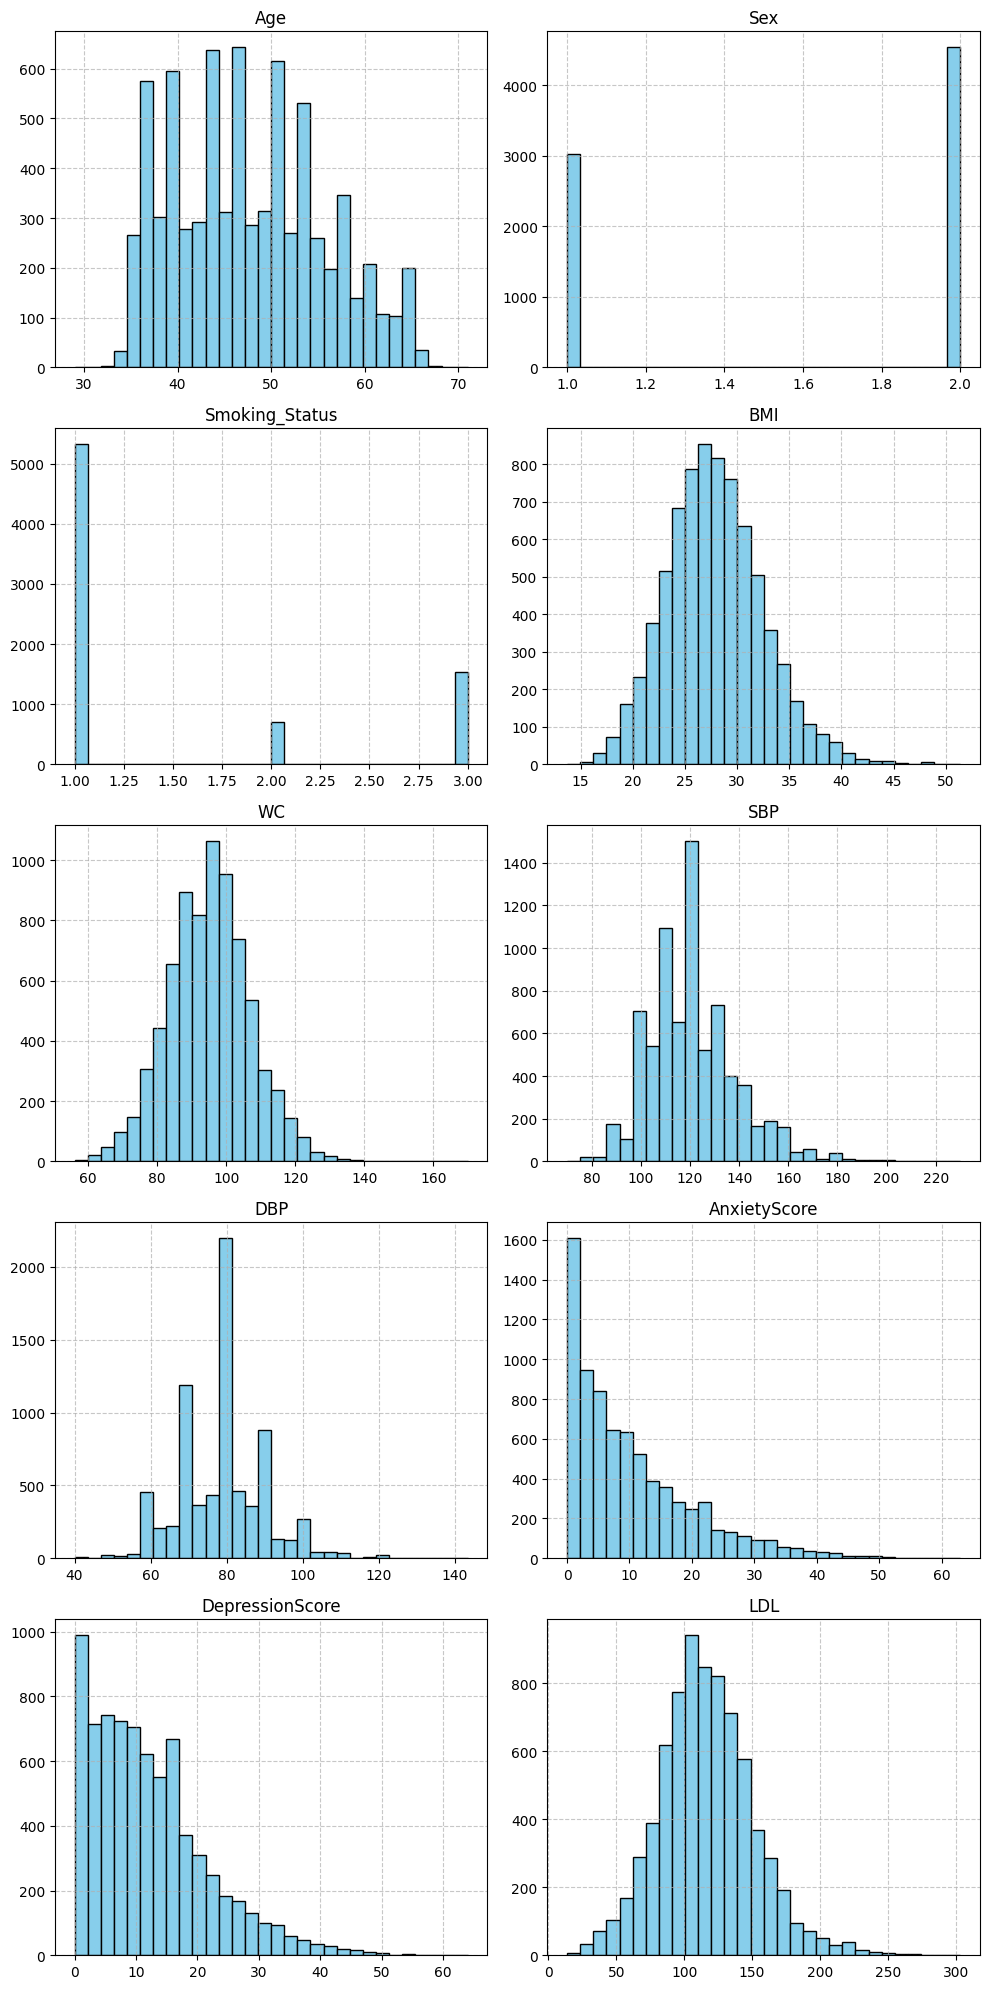

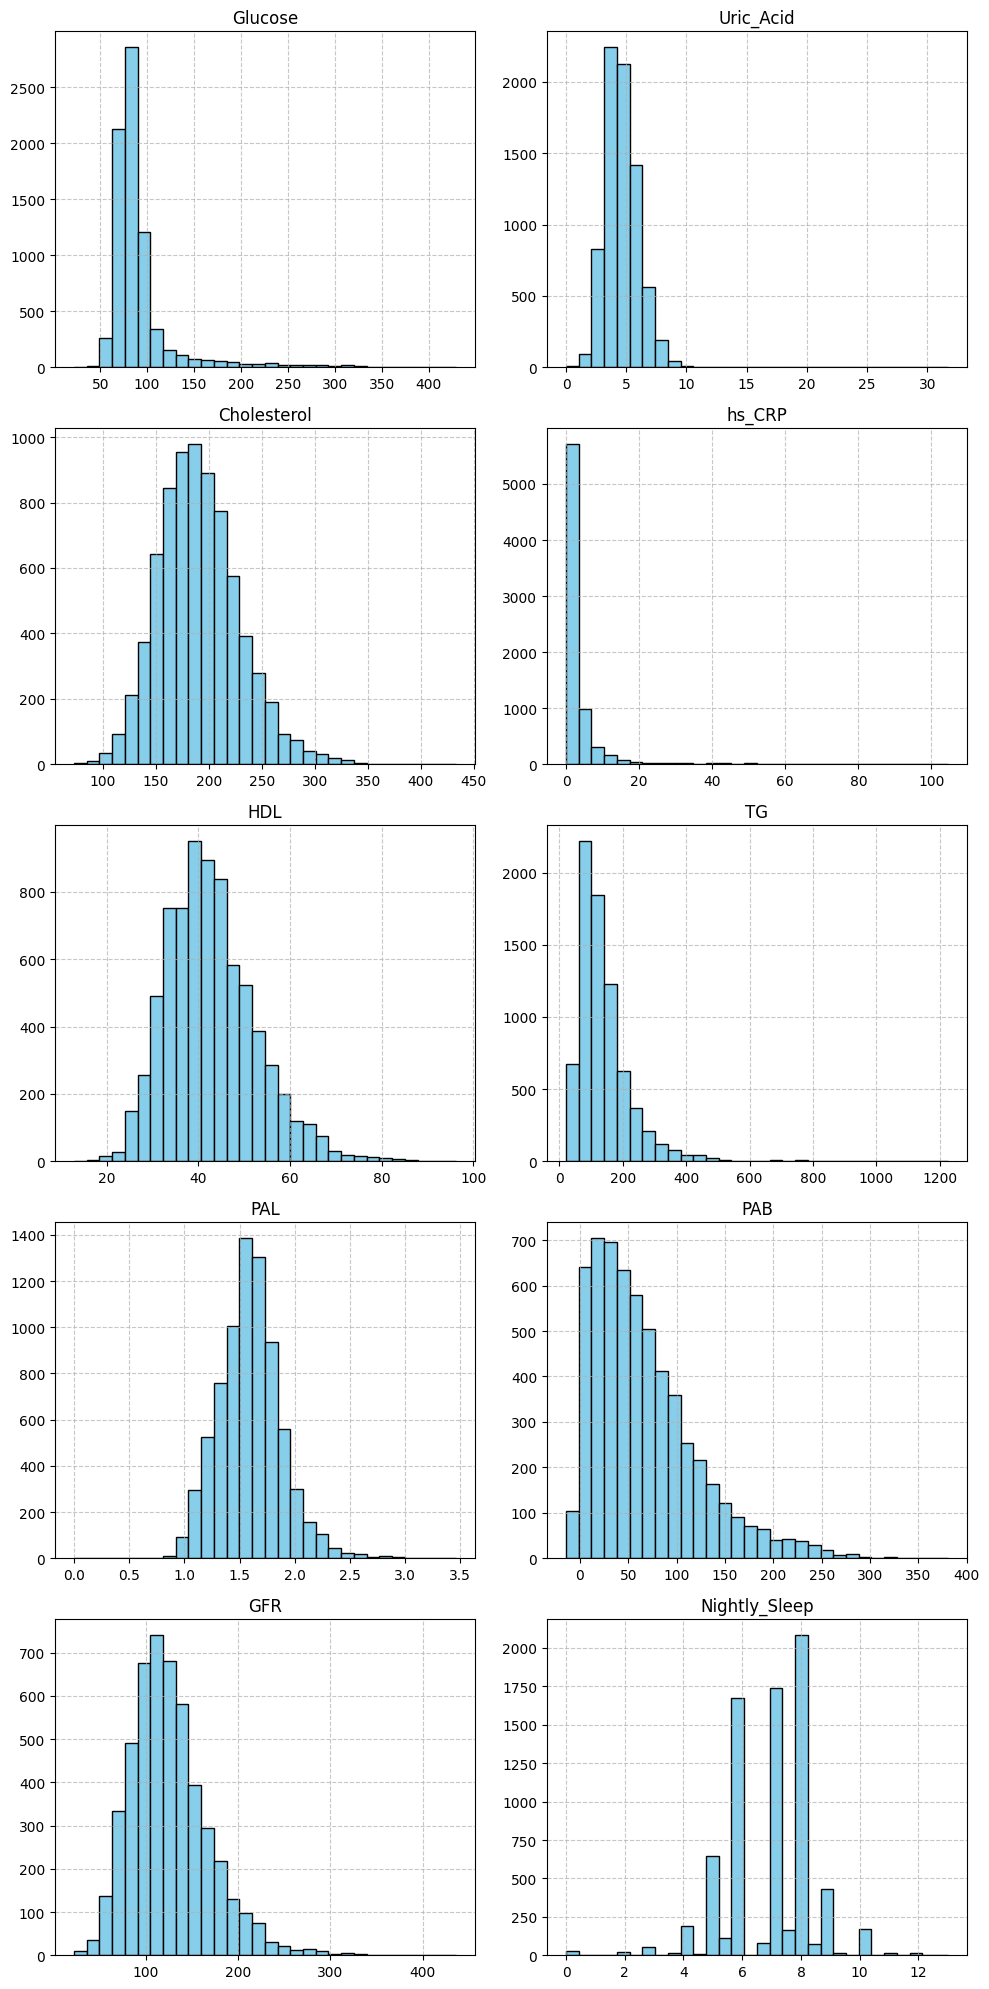

In [76]:
plot_histograms_grouped(X,path)

In [77]:
x_copy_clean_data, y_copy_clean_data, best_algo_clean_data, best_accuracy_clean_data,acc_holder_clean_data,changes_clean=handling_missing_data(X,Y)

drop_rows

impute_mean

impute_median

impute_class_mean

impute_class_median

ffill

bfill

interpolate

Model_imputation

Iterative_model_Imputation



/home/strix/Python/qenv/lib/python3.12/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


KNN_Imputation



In [78]:
changes_clean

[(24, 0),
 (27, 0),
 (2419, 0),
 (4385, 0),
 (5002, 0),
 (5854, 0),
 (258, 3),
 (1810, 3),
 (2100, 3),
 (2456, 3),
 (4510, 3),
 (4817, 3),
 (5897, 3),
 (6058, 3),
 (6198, 3),
 (6306, 3),
 (7031, 3),
 (1810, 4),
 (2456, 4),
 (4510, 4),
 (4898, 4),
 (5897, 4),
 (6058, 4),
 (7031, 4),
 (23, 5),
 (258, 5),
 (1507, 5),
 (2456, 5),
 (2530, 5),
 (2601, 5),
 (2712, 5),
 (2723, 5),
 (2869, 5),
 (4592, 5),
 (4594, 5),
 (4898, 5),
 (5168, 5),
 (5784, 5),
 (5843, 5),
 (5897, 5),
 (5999, 5),
 (6058, 5),
 (6126, 5),
 (6129, 5),
 (6789, 5),
 (6790, 5),
 (7042, 5),
 (23, 6),
 (258, 6),
 (1507, 6),
 (2456, 6),
 (2530, 6),
 (2601, 6),
 (2712, 6),
 (2723, 6),
 (2869, 6),
 (4592, 6),
 (4594, 6),
 (4898, 6),
 (5168, 6),
 (5784, 6),
 (5843, 6),
 (5897, 6),
 (5999, 6),
 (6058, 6),
 (6126, 6),
 (6129, 6),
 (6308, 6),
 (6484, 6),
 (6789, 6),
 (6790, 6),
 (7042, 6),
 (605, 7),
 (966, 7),
 (2789, 7),
 (6239, 7),
 (148, 8),
 (605, 8),
 (966, 8),
 (1554, 8),
 (2789, 8),
 (6239, 8),
 (53, 9),
 (121, 9),
 (200, 9),


In [79]:
x_copy_tame_outlier, y_copy_tame_outlier, best_algo_tame_outlier, best_accuracy_tame_outlier,acc_holder_tame_outlier,changes_outlier=taming_outliers(x_copy_clean_data,y_copy_clean_data)

IQR

LOF

iForest

SP

iNNe



In [80]:
changes_outlier

[(33, 3),
 (93, 3),
 (439, 3),
 (506, 3),
 (581, 3),
 (664, 3),
 (1251, 3),
 (1682, 3),
 (1908, 3),
 (2101, 3),
 (2560, 3),
 (2848, 3),
 (3669, 3),
 (3715, 3),
 (3802, 3),
 (6260, 3),
 (6430, 3),
 (7146, 3),
 (7387, 3),
 (179, 4),
 (279, 4),
 (283, 4),
 (2772, 4),
 (3715, 4),
 (6250, 4),
 (6321, 4),
 (7387, 4),
 (2, 5),
 (111, 5),
 (208, 5),
 (231, 5),
 (232, 5),
 (252, 5),
 (284, 5),
 (425, 5),
 (485, 5),
 (729, 5),
 (843, 5),
 (895, 5),
 (915, 5),
 (1171, 5),
 (1228, 5),
 (1257, 5),
 (1259, 5),
 (1618, 5),
 (1622, 5),
 (1850, 5),
 (1884, 5),
 (1897, 5),
 (2318, 5),
 (2320, 5),
 (2346, 5),
 (2451, 5),
 (2793, 5),
 (2796, 5),
 (2821, 5),
 (2909, 5),
 (2954, 5),
 (2975, 5),
 (3198, 5),
 (3255, 5),
 (3296, 5),
 (3359, 5),
 (3361, 5),
 (3532, 5),
 (3799, 5),
 (3839, 5),
 (3872, 5),
 (3902, 5),
 (4079, 5),
 (4081, 5),
 (4173, 5),
 (4196, 5),
 (4229, 5),
 (4273, 5),
 (4274, 5),
 (4412, 5),
 (4420, 5),
 (4434, 5),
 (4637, 5),
 (4914, 5),
 (4918, 5),
 (5036, 5),
 (5044, 5),
 (5045, 5),
 (5067

In [81]:
if(normalized):
    x_copy_normalization, y_copy_normalization, best_algo_normalization, best_accuracy_normalization,acc_holder_normalization=normalization(x_copy_tame_outlier,y_copy_tame_outlier)
else:
    x_copy_normalization=x_copy_tame_outlier.copy()
    y_copy_normalization=y_copy_tame_outlier.copy()
    best_algo_normalization="Not Normalized"

MinMaxScalarNorm

RobustScalarNorm

ZScoreNormalizationNorm



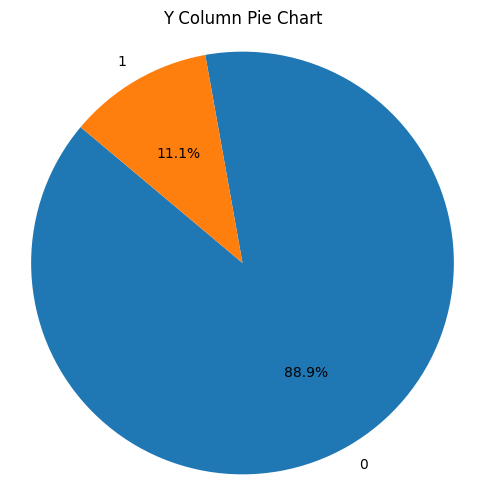

In [82]:
plot_pie_chart(Y,path=path,title="Y Column Pie Chart")

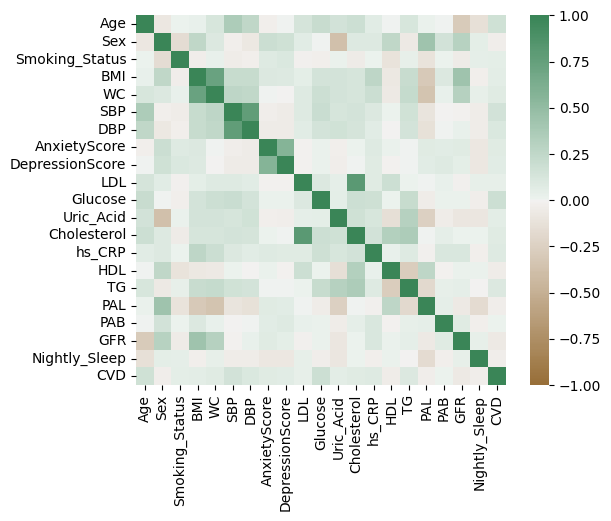

<Figure size 640x480 with 0 Axes>

In [83]:
joined_for_heatmap=x_copy_normalization.join(y_copy_normalization)

correlation_full_health = joined_for_heatmap.corr()

axis_corr = sns.heatmap(
correlation_full_health,
vmin=-1, vmax=1, center=0,
cmap=sns.diverging_palette(50, 500, n=500),
square=True
)
plt.show()
plt.savefig(f"{path}_heatmapBeforeFeature") 

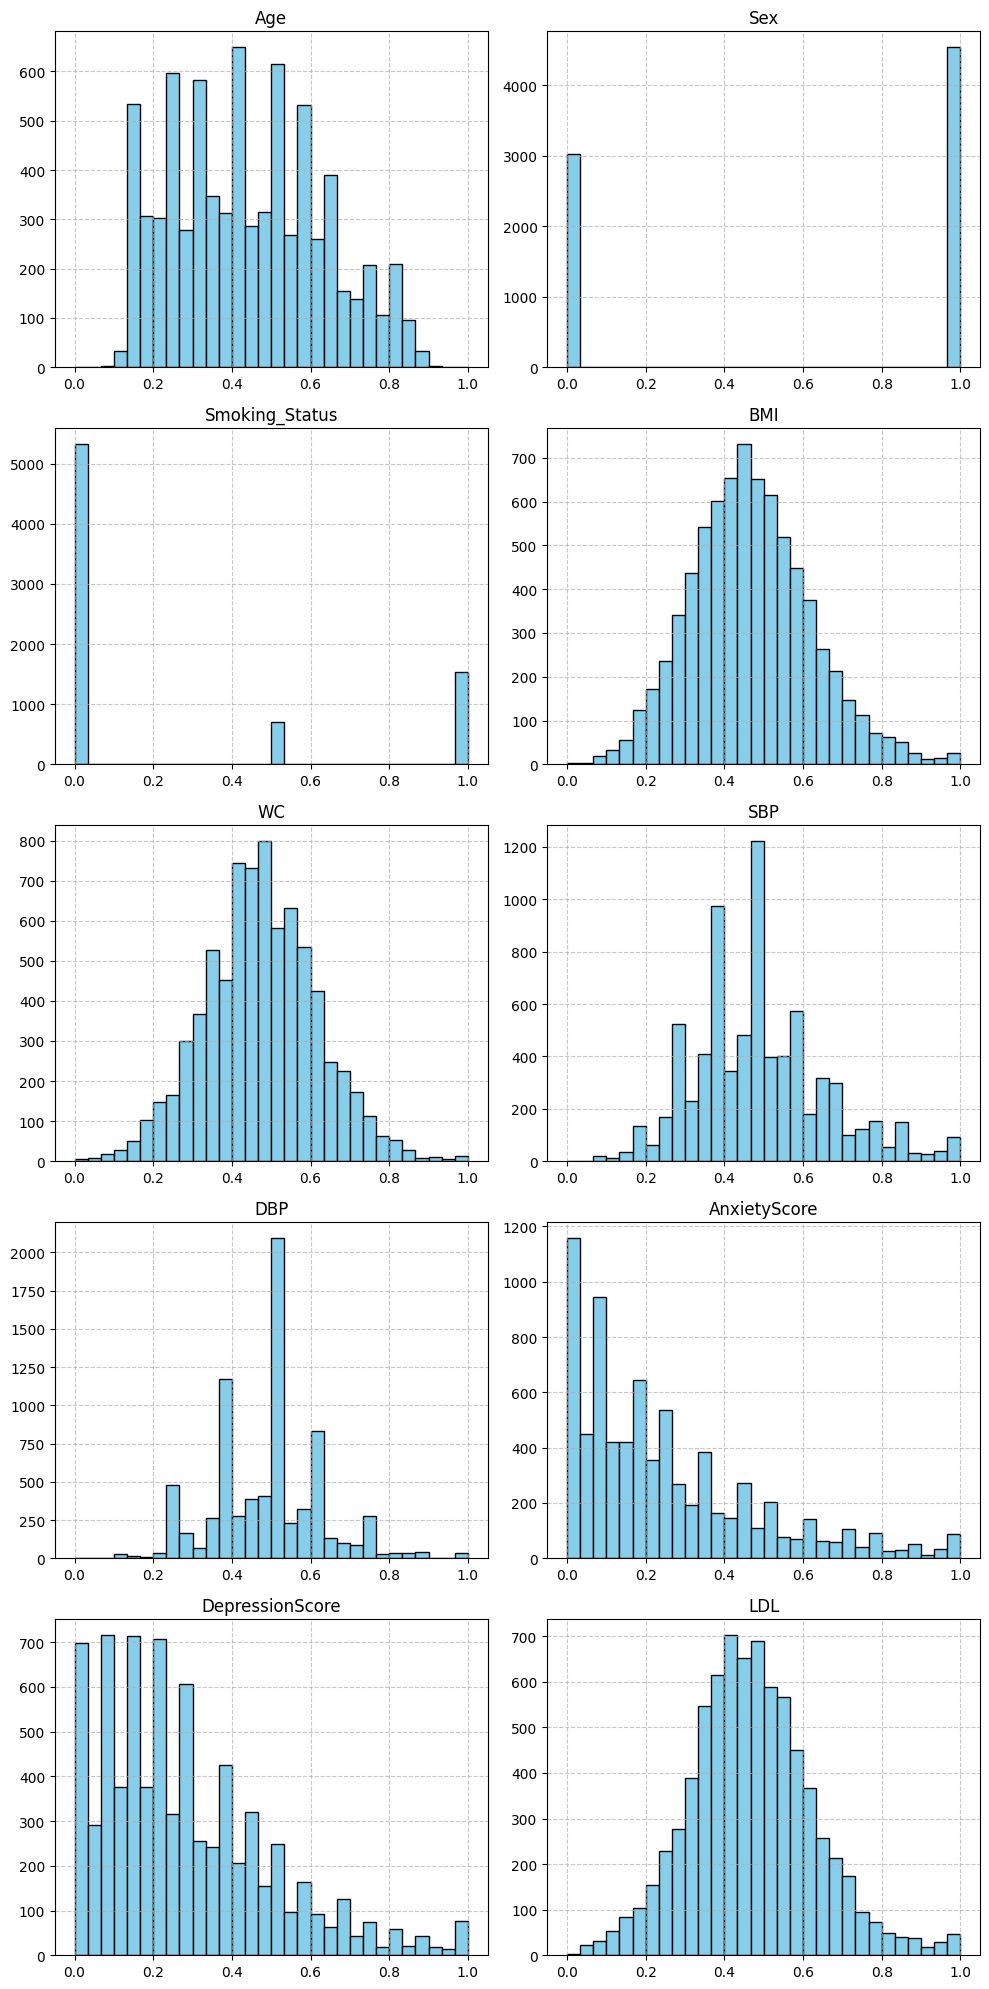

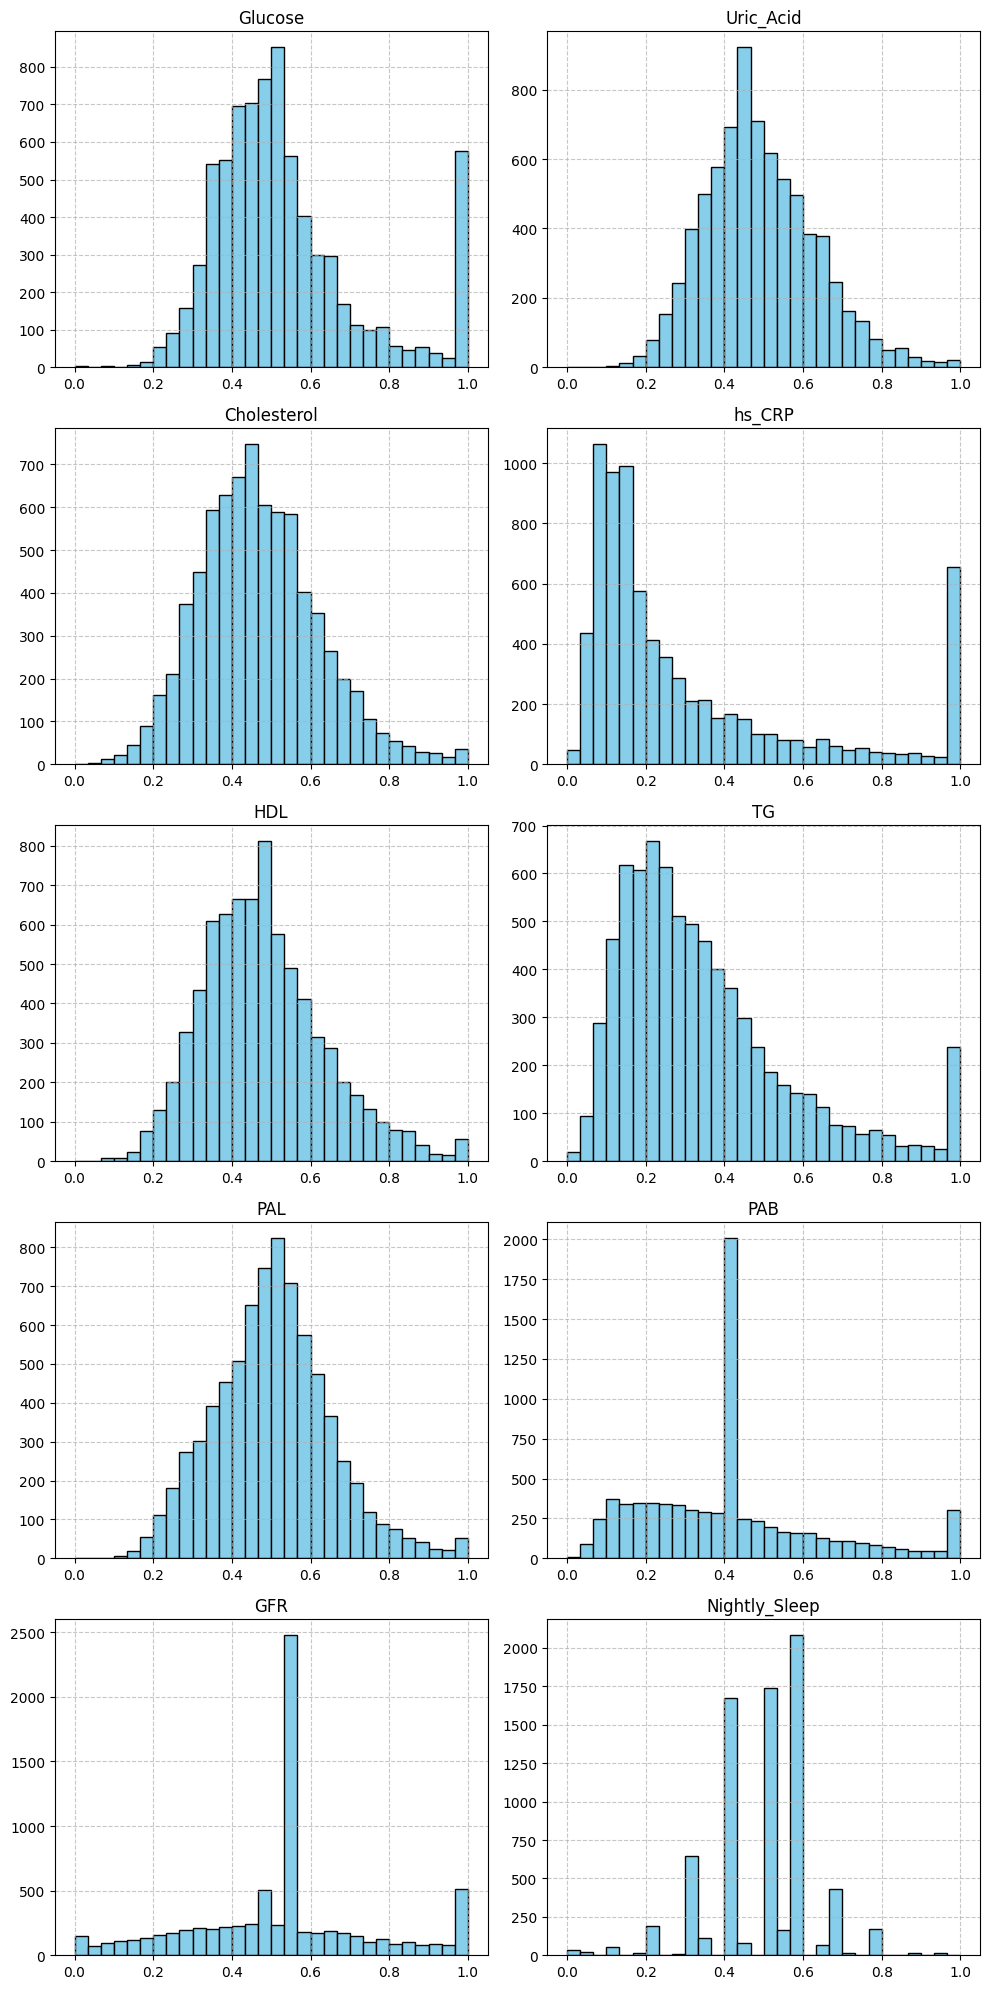

In [84]:
plot_histograms_grouped(x_copy_normalization,path=f"{path}_after_")

In [85]:
x_copy_feature_selection, y_copy_feature_selection, best_algo_feature_selection, best_accuracy_feature_selection,acc_holder_feature_selection,final_scores,final_result=feature_selection(x_copy_normalization,y_copy_normalization,categories)

Selected 15 features: ['SBP', 'hs_CRP', 'PAL', 'AnxietyScore', 'DBP', 'Age', 'Sex', 'GFR', 'Glucose', 'Smoking_Status', 'TG', 'PAB', 'BMI', 'WC', 'Nightly_Sleep']


In [86]:
final_scores

0.8779669212322903

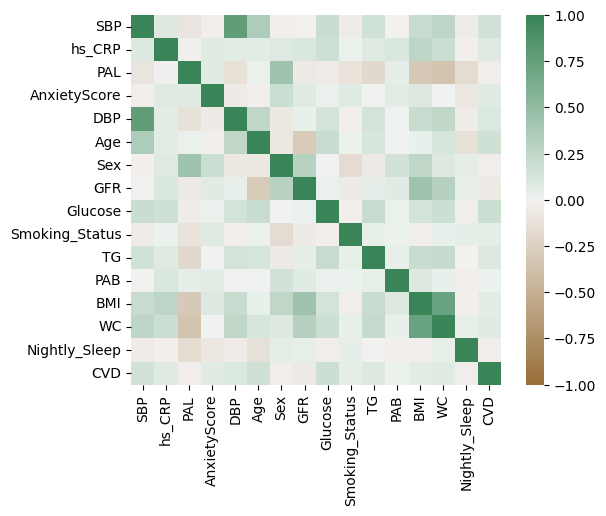

<Figure size 640x480 with 0 Axes>

In [87]:
joined_for_heatmap=x_copy_feature_selection.join(y_copy_feature_selection)
correlation_full_health = joined_for_heatmap.corr()

axis_corr = sns.heatmap(
correlation_full_health,
vmin=-1, vmax=1, center=0,
cmap=sns.diverging_palette(50, 500, n=500),
square=True
)
plt.show() 
plt.savefig(f"{path}_heatmapAfterFeature") 

In [88]:
x_train, x_test, y_train, y_test = train_test_split(x_copy_feature_selection, y_copy_feature_selection, test_size=0.2, random_state=42)
x_bal_train, y_bal_train, used_method = check_and_balance(x_train, y_train, train_and_evaluate)

Class imbalance detected. Testing balancing methods...
Method: random, Score: 0.8503
Method: smote, Score: 0.8167
Best balancing method: random with score: 0.8503


In [89]:
X_full = pd.concat([x_bal_train, x_test], axis=0).reset_index(drop=True)
y_full = pd.concat([y_bal_train, y_test], axis=0).reset_index(drop=True)
full_data = X_full.copy()
full_data["CVD"] = y_full
full_data.to_csv(f'{path}_balanced{"_and_normalized" if normalized else ""}.csv')

In [90]:
y_bal_train.value_counts()

CVD
0    5393
1    5393
Name: count, dtype: int64

In [91]:
model, best_algo_model_training, best_accuracy_model_training,acc_holder_model_training=model_training(x_bal_train,x_test,y_bal_train,y_test)

LogisticRegression

Running LogisticRegression with 45 model configurations...


/home/strix/Python/qenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/home/strix/Python/qenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/home/strix/Python/qenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/strix/Python/qenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/strix/Python/qenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warni

LogisticRegression custom score: 0.4331
KNN

Running KNeighbors with 24 model configurations...
KNeighbors custom score: 0.3850
NaiveBayes

Running GaussianNB with 3 model configurations...
GaussianNB custom score: 0.4320
RandomForest

Running RandomForestBased with 12 model configurations...
RandomForestBased custom score: 0.7278
XGBoost

Running XGBoostBased with 18 model configurations...


/home/strix/Python/qenv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:31:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/strix/Python/qenv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:31:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/strix/Python/qenv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:31:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/strix/Python/qenv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:31:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/strix/Python/qenv/lib/python3.12/site-pack

XGBoostBased custom score: 0.7227
LightGBM

Running LightGBM with 40 model configurations...
LightGBM custom score: 0.7707
CatBoost

Running CatBoost with 12 model configurations...
CatBoost custom score: 0.7423
GradientBoosting

Running GradientBoosting with 8 model configurations...
GradientBoosting custom score: 0.6660
NeuralNetwork

Running NeuralNetworkBased with 6 model configurations...


/home/strix/Python/qenv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/strix/Python/qenv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/strix/Python/qenv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/strix/Python/qenv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/strix/Python/qenv/lib/pyth

NeuralNetworkBased custom score: 0.3376
Running LightGBM with 40 model configurations...
LightGBM custom score: 0.7707


In [92]:
print(model)

LGBMClassifier(class_weight='balanced', n_estimators=200, num_leaves=63,
               random_state=42, verbose=-1)


In [93]:
print(best_accuracy_model_training)

0.7706666550952148


NameError: name 'final_score' is not defined

In [101]:
def save_pipeline_summary(
    final_result,
    model,
    best_algo_clean_data,
    best_algo_tame_outlier,
    best_algo_normalization,
    best_algo_feature_selection,
    best_algo_model_training,
    best_accuracy_model_training,
    file_path="pipeline_summary.txt"
):
    with open(file_path, "w") as f:
        f.write(f"{final_result}\n\n")


        f.write(f"Model Config:\n{model}\n\n")

        f.write(f"Final_Acc: {best_accuracy_model_training}\n\n")

        f.write(f"clean: {best_algo_clean_data}\n")
        f.write(f"outlier: {best_algo_tame_outlier}\n")
        f.write(f"norm: {best_algo_normalization}\n")
        f.write(f"feature: {best_algo_feature_selection}\n")
        f.write(f"model: {best_algo_model_training}\n")

    print(f"Summary saved to {file_path}")
save_pipeline_summary(final_result,model,final_scores,best_algo_clean_data,best_algo_tame_outlier,best_algo_normalization,best_algo_feature_selection,best_algo_model_training,best_accuracy_model_training,file_path=f"./{path}_logs_{"normalized" if normalized else ""}.txt")

TypeError: save_pipeline_summary() got multiple values for argument 'file_path'